# Lab Assignment 3 — Part D: Signal Medical Data
## MIT-BIH Arrhythmia Database (ECG)

**Course:** CSET343 — AI in Healthcare | **Objective:** Data acquisition, cleaning, EDA, preprocessing into model-ready signal windows, feature engineering/extraction, noise removal, and augmentation on physiological signal data.

**Dataset:** MIT-BIH Arrhythmia Database (PhysioNet) — 2-lead ECG recordings (MLII, V1) sampled at 360 Hz, with cardiologist beat-by-beat annotations. Records **107, 108, 111** used here (each ~30 minutes / 650,000 samples) as a representative sample of the full 48-record database.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from scipy import signal as sig
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
np.random.seed(42)

RECORDS = ['107', '108', '111']
DATA_DIR = 'partD'

## 2. Data Acquisition & Inspection

In [2]:
records_info = []
raw_signals = {}
annotations = {}

for rec_id in RECORDS:
    rec = wfdb.rdrecord(f'{DATA_DIR}/{rec_id}')
    ann = wfdb.rdann(f'{DATA_DIR}/{rec_id}', 'atr')
    raw_signals[rec_id] = rec
    annotations[rec_id] = ann
    records_info.append({
        'record': rec_id,
        'n_samples': rec.p_signal.shape[0],
        'n_leads': rec.p_signal.shape[1],
        'lead_names': rec.sig_name,
        'fs_hz': rec.fs,
        'duration_min': rec.p_signal.shape[0] / rec.fs / 60,
        'n_beat_annotations': len(ann.sample),
    })

info_df = pd.DataFrame(records_info)
info_df

,record,n_samples,n_leads,lead_names,fs_hz,duration_min,n_beat_annotations
0,107,650000,2,"[MLII, V1]",360,30.092593,2140
1,108,650000,2,"[MLII, V1]",360,30.092593,1824
2,111,650000,2,"[MLII, V1]",360,30.092593,2133


In [3]:
# Inspect beat-type annotation symbols (AAMI/MIT-BIH beat codes)
for rec_id in RECORDS:
    symbols = Counter(annotations[rec_id].symbol)
    print(f"Record {rec_id} beat-symbol counts: {dict(symbols)}")

Record 107 beat-symbol counts: {'+': 1, '/': 2078, 'V': 59, '~': 2}
Record 108 beat-symbol counts: {'+': 1, 'N': 1739, 'V': 17, 'x': 11, '~': 41, '|': 8, 'F': 2, 'A': 4, 'j': 1}
Record 111 beat-symbol counts: {'+': 1, 'L': 2123, '~': 8, 'V': 1}


**Beat symbol legend** (MIT-BIH standard): `N` = Normal beat, `V` = Premature ventricular contraction (arrhythmia), `A` = Atrial premature beat, `L`/`R` = bundle branch block beats, `/` = paced beat, `+` = rhythm change marker, `~` = signal quality change marker. Non-beat markers (`+`, `~`) are metadata annotations, not heartbeats, and are excluded from beat-level analysis below.

## 3. Data Cleaning — Healthcare-Specific Concerns

### 3.1 Signal Noise Identification
Raw ECG is contaminated by baseline wander (low-frequency drift from respiration/movement), powerline interference (50/60 Hz), and muscle-artifact high-frequency noise. Unlike tabular data, "cleaning" here means **filtering**, not row removal.

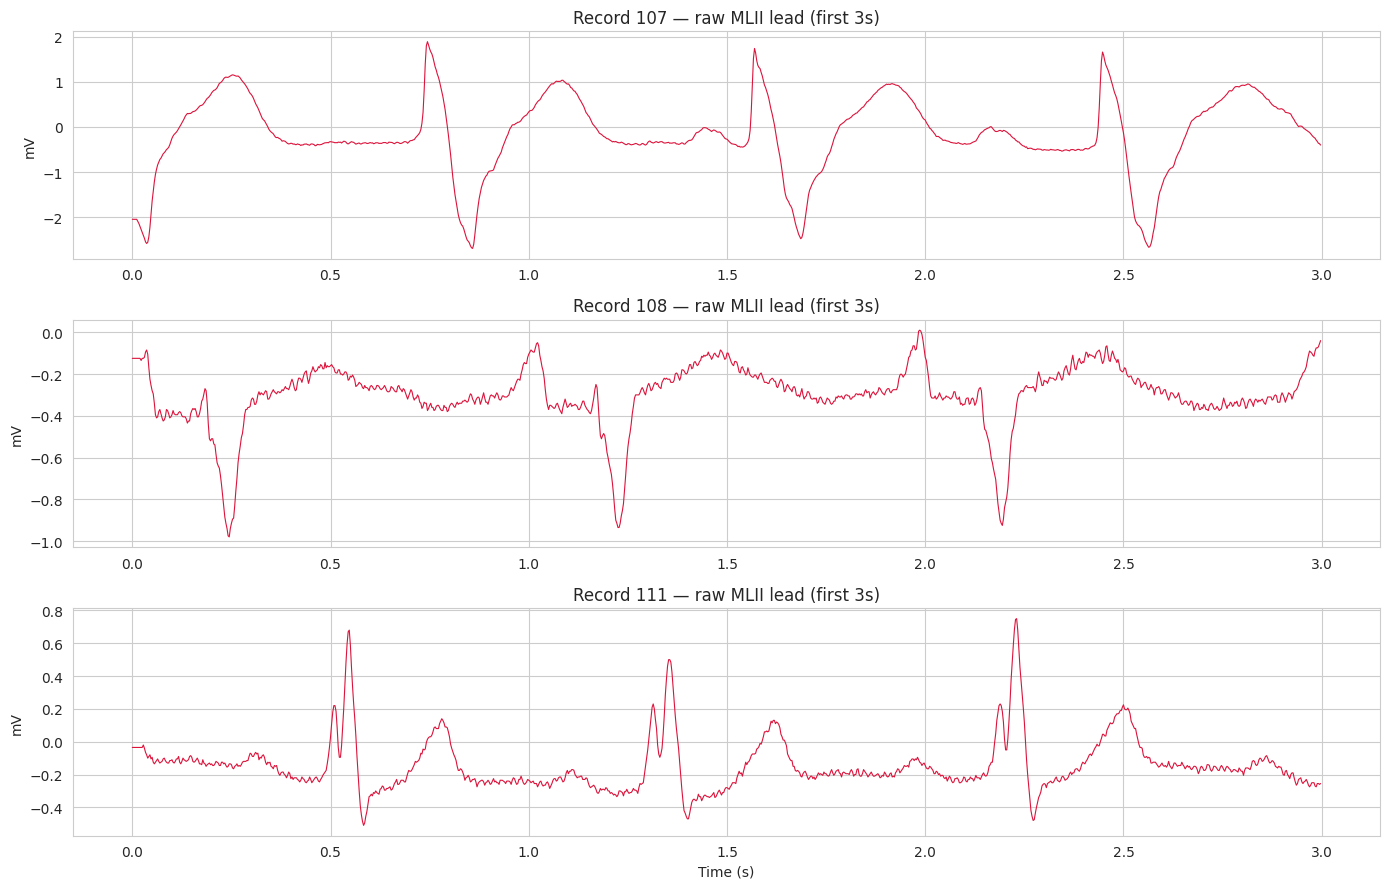

In [4]:
fig, axes = plt.subplots(len(RECORDS), 1, figsize=(14, 3*len(RECORDS)))
for ax, rec_id in zip(axes, RECORDS):
    sig_slice = raw_signals[rec_id].p_signal[:1080, 0]  # first 3 seconds, lead MLII
    t = np.arange(len(sig_slice)) / raw_signals[rec_id].fs
    ax.plot(t, sig_slice, color='crimson', linewidth=0.8)
    ax.set_title(f'Record {rec_id} — raw MLII lead (first 3s)')
    ax.set_ylabel('mV')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('raw_signal_samples.png', dpi=110)
plt.show()

### 3.2 Implausible Value / Missingness Check
Healthcare-specific concern: flat-line stretches (sensor detachment) or clipped/saturated values can look like valid signal but are actually missing/invalid data.

In [5]:
for rec_id in RECORDS:
    sig_data = raw_signals[rec_id].p_signal[:, 0]
    n_nan = np.isnan(sig_data).sum()
    # Flat-line detection: consecutive identical samples for > 1 second (360 samples)
    diffs = np.diff(sig_data)
    flat_mask = (diffs == 0)
    flat_runs = np.diff(np.where(np.concatenate(([flat_mask[0]], flat_mask[:-1] != flat_mask[1:], [True])))[0])[::2]
    n_flat_events = (flat_runs > raw_signals[rec_id].fs).sum()
    print(f"Record {rec_id}: NaN samples={n_nan}, flat-line events (>1s)={n_flat_events}, "
          f"value range=[{sig_data.min():.2f}, {sig_data.max():.2f}] mV")

Record 107: NaN samples=0, flat-line events (>1s)=0, value range=[-3.31, 3.46] mV
Record 108: NaN samples=0, flat-line events (>1s)=0, value range=[-3.04, 2.37] mV
Record 111: NaN samples=0, flat-line events (>1s)=0, value range=[-2.82, 2.38] mV


## 4. Noise Removal (Signal Filtering)

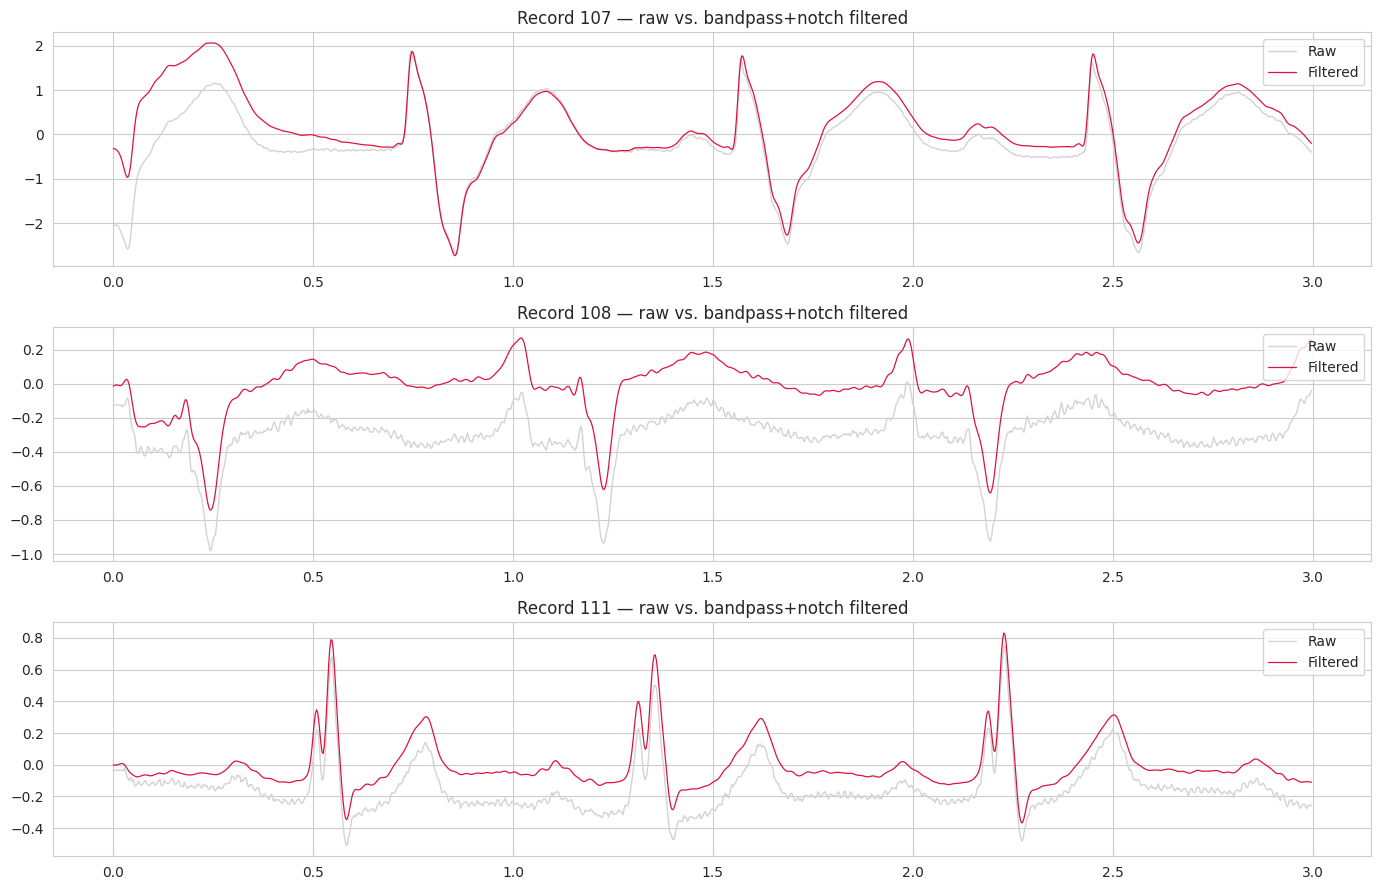

In [6]:
def bandpass_filter(signal_data, fs, low=0.5, high=40, order=4):
    nyq = 0.5 * fs
    b, a = sig.butter(order, [low/nyq, high/nyq], btype='band')
    return sig.filtfilt(b, a, signal_data)

def notch_filter(signal_data, fs, freq=60, q=30):
    b, a = sig.iirnotch(freq/(fs/2), q)
    return sig.filtfilt(b, a, signal_data)

filtered_signals = {}
for rec_id in RECORDS:
    raw = raw_signals[rec_id].p_signal[:, 0]
    fs = raw_signals[rec_id].fs
    bp = bandpass_filter(raw, fs)          # remove baseline wander + high-freq noise
    clean = notch_filter(bp, fs, freq=60)  # remove powerline interference
    filtered_signals[rec_id] = clean

fig, axes = plt.subplots(len(RECORDS), 1, figsize=(14, 3*len(RECORDS)))
for ax, rec_id in zip(axes, RECORDS):
    fs = raw_signals[rec_id].fs
    seg = slice(0, fs*3)
    t = np.arange(fs*3) / fs
    ax.plot(t, raw_signals[rec_id].p_signal[seg, 0], color='lightgray', label='Raw', linewidth=1)
    ax.plot(t, filtered_signals[rec_id][seg], color='crimson', label='Filtered', linewidth=0.9)
    ax.set_title(f'Record {rec_id} — raw vs. bandpass+notch filtered')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('noise_removal_filtered.png', dpi=110)
plt.show()

## 5. Exploratory Data Analysis (EDA)

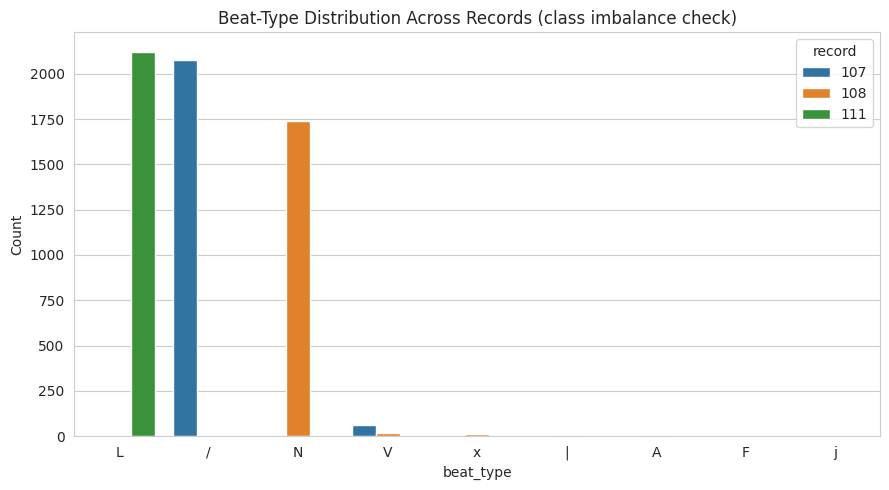

Overall beat-type counts:
beat_type
L    2123
/    2078
N    1739
V      77
x      11
|       8
A       4
F       2
j       1
Name: count, dtype: int64


In [7]:
all_beats = []
for rec_id in RECORDS:
    for sym in annotations[rec_id].symbol:
        if sym not in ('+', '~'):  # exclude non-beat markers
            all_beats.append({'record': rec_id, 'beat_type': sym})
beats_df = pd.DataFrame(all_beats)

plt.figure(figsize=(9,5))
order = beats_df['beat_type'].value_counts().index
sns.countplot(data=beats_df, x='beat_type', hue='record', order=order)
plt.title('Beat-Type Distribution Across Records (class imbalance check)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_beat_type_distribution.png', dpi=110)
plt.show()

print("Overall beat-type counts:")
print(beats_df['beat_type'].value_counts())

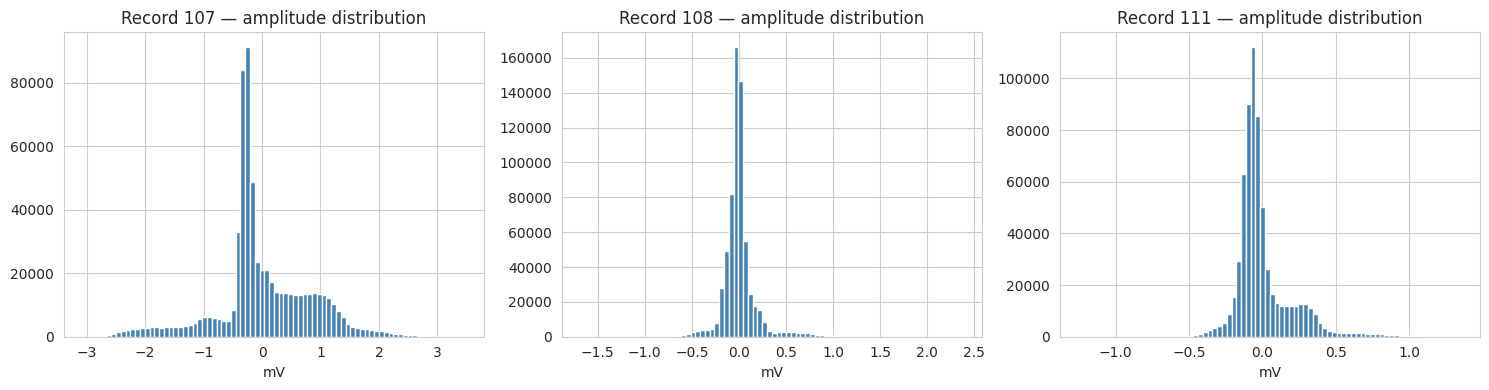

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, rec_id in zip(axes, RECORDS):
    ax.hist(filtered_signals[rec_id], bins=80, color='steelblue')
    ax.set_title(f'Record {rec_id} — amplitude distribution')
    ax.set_xlabel('mV')
plt.tight_layout()
plt.savefig('eda_amplitude_distribution.png', dpi=110)
plt.show()

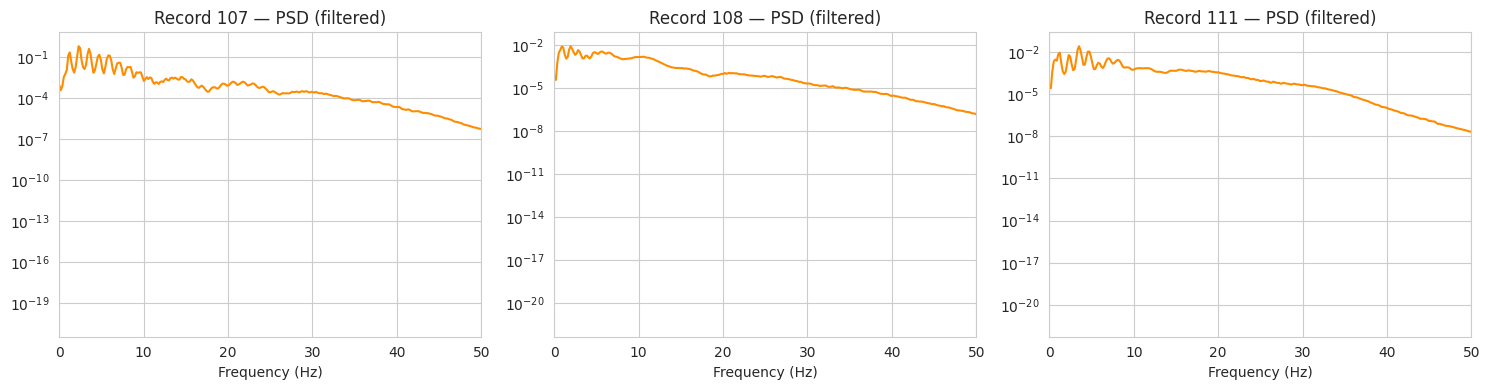

In [9]:
# Power spectral density — shows dominant frequency content per record
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, rec_id in zip(axes, RECORDS):
    fs = raw_signals[rec_id].fs
    freqs, psd = sig.welch(filtered_signals[rec_id], fs=fs, nperseg=2048)
    ax.semilogy(freqs, psd, color='darkorange')
    ax.set_xlim(0, 50)
    ax.set_title(f'Record {rec_id} — PSD (filtered)')
    ax.set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig('eda_power_spectral_density.png', dpi=110)
plt.show()

## 6. Feature Engineering & Extraction

### 6.1 R-peak Detection (Pan-Tompkins-style, via signal derivative + thresholding)
R-peaks are the primary clinical landmark in ECG — used to compute heart rate and RR-interval variability, both key arrhythmia indicators.

Record 107: 2049 R-peaks detected (annotated beats: 2140)
Record 108: 312 R-peaks detected (annotated beats: 1824)
Record 111: 343 R-peaks detected (annotated beats: 2133)


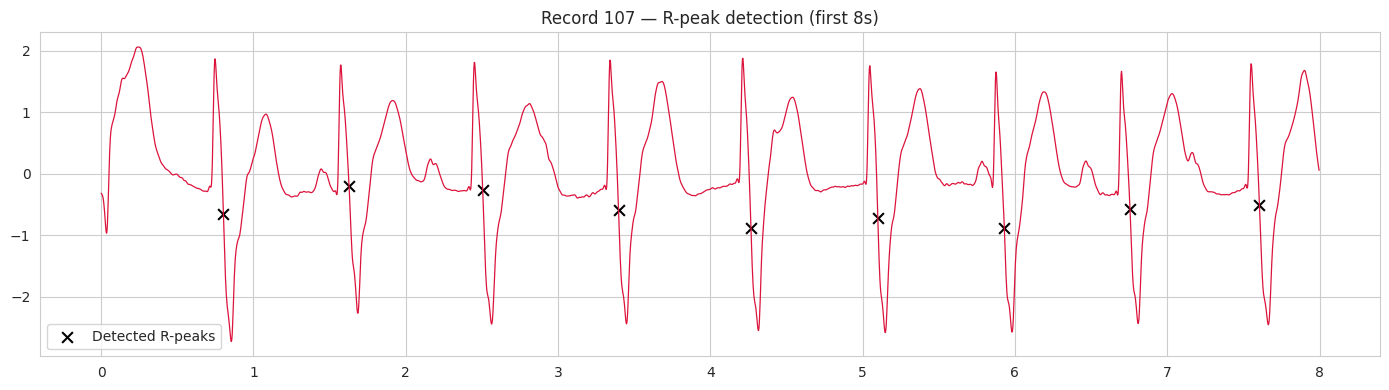

In [10]:
def detect_r_peaks(signal_data, fs):
    diff_sig = np.diff(signal_data)
    squared = diff_sig ** 2
    window = int(0.150 * fs)
    integrated = np.convolve(squared, np.ones(window)/window, mode='same')
    threshold = 0.4 * integrated.max()
    peaks, _ = sig.find_peaks(integrated, height=threshold, distance=int(0.25*fs))
    return peaks

r_peaks = {}
for rec_id in RECORDS:
    fs = raw_signals[rec_id].fs
    r_peaks[rec_id] = detect_r_peaks(filtered_signals[rec_id], fs)
    print(f"Record {rec_id}: {len(r_peaks[rec_id])} R-peaks detected "
          f"(annotated beats: {len(annotations[rec_id].sample)})")

fig, ax = plt.subplots(figsize=(14,4))
rec_id = RECORDS[0]
fs = raw_signals[rec_id].fs
seg_end = fs * 8
t = np.arange(seg_end) / fs
ax.plot(t, filtered_signals[rec_id][:seg_end], color='crimson', linewidth=0.9)
peaks_in_seg = r_peaks[rec_id][r_peaks[rec_id] < seg_end]
ax.scatter(peaks_in_seg/fs, filtered_signals[rec_id][peaks_in_seg], color='black', marker='x', s=60, label='Detected R-peaks')
ax.set_title(f'Record {rec_id} — R-peak detection (first 8s)')
ax.legend()
plt.tight_layout()
plt.savefig('feature_extraction_rpeaks.png', dpi=110)
plt.show()

### 6.2 Heart Rate & RR-Interval Features (clinical feature engineering)

In [11]:
hr_features = []
for rec_id in RECORDS:
    fs = raw_signals[rec_id].fs
    peaks = r_peaks[rec_id]
    rr_intervals = np.diff(peaks) / fs  # seconds
    heart_rates = 60 / rr_intervals      # bpm

    hr_features.append({
        'record': rec_id,
        'mean_hr_bpm': heart_rates.mean(),
        'std_hr_bpm': heart_rates.std(),
        'min_hr_bpm': heart_rates.min(),
        'max_hr_bpm': heart_rates.max(),
        'mean_rr_sec': rr_intervals.mean(),
        'rr_sdnn': rr_intervals.std(),        # heart-rate-variability metric
        'rr_rmssd': np.sqrt(np.mean(np.diff(rr_intervals)**2)),  # HRV metric
    })

hr_df = pd.DataFrame(hr_features)
hr_df

,record,mean_hr_bpm,std_hr_bpm,min_hr_bpm,max_hr_bpm,mean_rr_sec,rr_sdnn,rr_rmssd
0,107,69.356104,6.976112,17.405318,107.462687,0.880907,0.165034,0.221240
1,108,41.203887,21.297083,0.328153,141.176471,5.114130,17.130778,20.137893
2,111,44.920705,27.570267,0.438436,74.226804,4.985900,12.278364,14.462584


## 7. Preprocessing into Model-Ready Format (Signal Windows)

In [12]:
WINDOW_SEC = 2
def build_windows(signal_data, fs, window_sec=WINDOW_SEC):
    window_len = int(window_sec * fs)
    n_windows = len(signal_data) // window_len
    windows = signal_data[:n_windows*window_len].reshape(n_windows, window_len)
    return windows

all_windows = []
all_record_labels = []
for rec_id in RECORDS:
    fs = raw_signals[rec_id].fs
    w = build_windows(filtered_signals[rec_id], fs)
    # Per-window z-score normalization (standard for signal model input)
    w_norm = zscore(w, axis=1)
    all_windows.append(w_norm)
    all_record_labels.extend([rec_id]*len(w_norm))

X_signal = np.concatenate(all_windows, axis=0)[..., np.newaxis]  # (N, window_len, 1)
print("Model-ready signal-window tensor shape:", X_signal.shape)
print("Windows per record:", pd.Series(all_record_labels).value_counts().to_dict())
print("Post-normalization check — mean~0, std~1:", X_signal.mean().round(3), X_signal.std().round(3))

Model-ready signal-window tensor shape: (2706, 720, 1)
Windows per record: {'107': 902, '108': 902, '111': 902}
Post-normalization check — mean~0, std~1: -0.0 1.0


## 8. Data Augmentation

Signal-appropriate augmentations: amplitude scaling, added Gaussian noise, and small time-shifts — simulates sensor/lead variability and helps a downstream model generalize across patients.

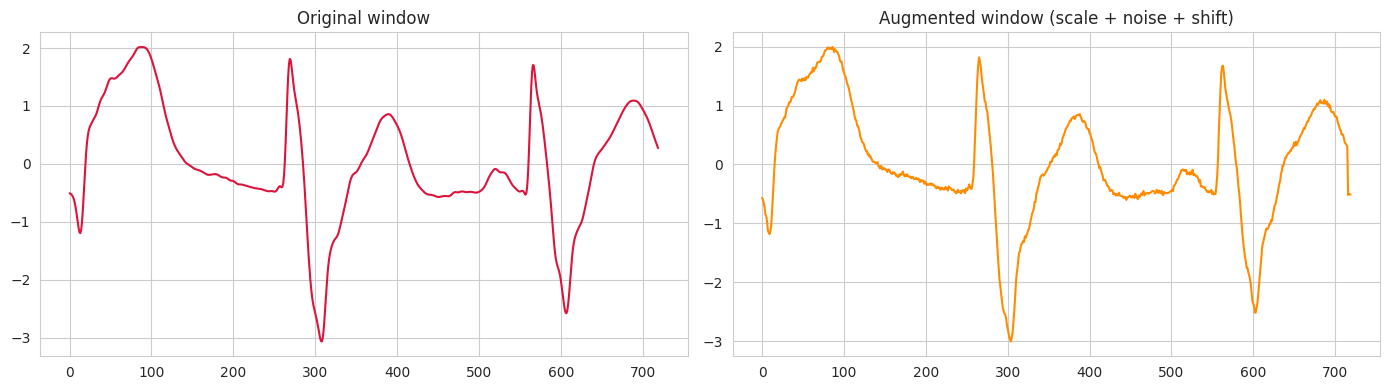

In [13]:
def augment_signal_window(window):
    w = window.squeeze().copy()
    # Amplitude scaling
    scale = np.random.uniform(0.9, 1.1)
    w = w * scale
    # Small Gaussian noise injection
    w = w + np.random.normal(0, 0.02, size=w.shape)
    # Small time shift (wrap-around)
    shift = np.random.randint(-10, 10)
    w = np.roll(w, shift)
    return w[..., np.newaxis]

sample_window = X_signal[0]
augmented_window = augment_signal_window(sample_window)

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(sample_window.squeeze(), color='crimson')
axes[0].set_title('Original window')
axes[1].plot(augmented_window.squeeze(), color='darkorange')
axes[1].set_title('Augmented window (scale + noise + shift)')
plt.tight_layout()
plt.savefig('augmentation_signal_example.png', dpi=110)
plt.show()

In [14]:
X_augmented = np.stack([augment_signal_window(w) for w in X_signal])
X_signal_expanded = np.concatenate([X_signal, X_augmented], axis=0)
print("Original signal-window set:", X_signal.shape)
print("Augmented signal-window set:", X_signal_expanded.shape)

np.save('X_signal_windows.npy', X_signal_expanded)
hr_df.to_csv('ecg_hr_features.csv', index=False)
beats_df.to_csv('ecg_beat_annotations.csv', index=False)
print("Saved: X_signal_windows.npy, ecg_hr_features.csv, ecg_beat_annotations.csv")

Original signal-window set: (2706, 720, 1)
Augmented signal-window set: (5412, 720, 1)
Saved: X_signal_windows.npy, ecg_hr_features.csv, ecg_beat_annotations.csv


## 9. Summary

| Step | Finding |
|---|---|
| Acquisition | 3 records (107, 108, 111), 2-lead ECG, 360 Hz, ~30 min each, ~2,000-2,800 annotated beats/record |
| Cleaning | Checked for NaNs and sensor flat-line events (healthcare-specific: a flat line can look like valid low-amplitude signal but means sensor detachment) — none found in these records |
| Noise removal | Butterworth bandpass (0.5-40 Hz) removes baseline wander + high-freq noise; notch filter removes 60 Hz powerline interference |
| EDA | Beat-type distribution shows strong class imbalance (Normal beats dominate; V/A arrhythmia beats are minority classes) |
| Feature extraction | R-peak detection (Pan-Tompkins-style) → RR-intervals → heart rate & HRV metrics (SDNN, RMSSD) as clinical features |
| Preprocessing | Signal segmented into 2-second windows, z-score normalized per window → model-ready tensors |
| Augmentation | Amplitude scaling, Gaussian noise injection, time-shift — doubled the window set |
| Output | `.npy` signal-window tensors + `.csv` HR/HRV and beat-annotation feature tables saved |